# Data Understanding And Processing

This notebook is for understanding the competition data and the preprocessing logic before model training. It checks data shape, missing labels, weekly target schedule, score distribution, train/test alignment, and demonstrates how one 91-day weather window is converted into tabular features.

In [14]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from make_features import (
    HORIZONS,
    WEATHER_COLS,
    WINDOW_DAYS,
    build_test_features,
    build_training_set_for_horizon,
    compute_window_features,
    read_test_csv,
    read_train_csv,
)

TRAIN_CSV = PROJECT_ROOT / "data" / "train.csv"
TEST_CSV = PROJECT_ROOT / "data" / "test.csv"
SAMPLE_SUBMISSION = PROJECT_ROOT / "sample_submission.csv"

pd.set_option("display.max_columns", 80)
PROJECT_ROOT

PosixPath('/home/mike/NYCU/2026_Spring/final')

## Load Data

The date strings are anonymized and should be treated mostly as ordered text/index signals, not as real calendar dates.

In [15]:
train_df = read_train_csv(TRAIN_CSV)
test_df = read_test_csv(TEST_CSV)
sample_df = pd.read_csv(SAMPLE_SUBMISSION)

print("train:", train_df.shape)
print("test :", test_df.shape)
print("sample:", sample_df.shape)
print("train regions:", train_df["region_id"].nunique())
print("test regions :", test_df["region_id"].nunique())
print("sample regions:", sample_df["region_id"].nunique())

train_df.head()

train: (12319040, 17)
test : (204568, 16)
sample: (2248, 6)
train regions: 2248
test regions : 2248
sample regions: 2248


,region_id,date,prec,surf_pre,humidity,tmp,dp_tmp,wb_tmp,tmp_max,tmp_min,tmp_range,surf_tmp,wind,wind_max,wind_min,wind_range,score
0,R1,3004-12-31,0.00,101.269997,3.76,5.89,-0.140000,-0.110000,14.870000,-2.37,17.240000,4.230000,1.45,2.58,0.24,2.34,NaN
1,R1,3005-01-01,0.00,101.260002,5.37,8.81,4.590000,4.600000,17.280001,1.14,16.139999,7.960000,1.83,2.38,1.18,1.21,NaN
2,R1,3005-01-02,0.01,100.809998,9.32,13.09,12.740000,12.740000,17.379999,8.21,9.170000,12.960000,1.96,2.49,1.39,1.09,NaN
3,R1,3005-01-03,0.02,100.510002,11.40,16.01,16.080000,16.080000,19.240000,13.77,5.470000,15.820000,2.13,2.67,1.74,0.93,NaN
4,R1,3005-01-04,1.93,100.160004,12.20,17.98,17.040001,17.040001,22.850000,14.27,8.580000,17.860001,2.91,4.25,2.13,2.11,NaN


## Columns And Missing Values

Weather columns are daily observations. `score` is sparse because labels only appear once per week.

In [16]:
display(pd.DataFrame({
    "dtype": train_df.dtypes.astype(str),
    "missing": train_df.isna().sum(),
    "missing_rate": train_df.isna().mean(),
}))

print("weather columns:", WEATHER_COLS)

,dtype,missing,missing_rate
region_id,string,0,0.000000
date,str,0,0.000000
prec,float32,0,0.000000
surf_pre,float32,0,0.000000
humidity,float32,0,0.000000
tmp,float32,0,0.000000
dp_tmp,float32,0,0.000000
wb_tmp,float32,0,0.000000
tmp_max,float32,0,0.000000
tmp_min,float32,0,0.000000


weather columns: ['prec', 'surf_pre', 'humidity', 'tmp', 'dp_tmp', 'wb_tmp', 'tmp_max', 'tmp_min', 'tmp_range', 'surf_tmp', 'wind', 'wind_max', 'wind_min', 'wind_range']


## Region Lengths

Each training region has the same number of daily rows. Each test region has exactly one 91-day block.

In [17]:
train_lengths = train_df.groupby("region_id", sort=False).size()
test_lengths = test_df.groupby("region_id", sort=False).size()

print("train row count per region")
display(train_lengths.describe())
display(train_lengths.value_counts().head())

print("test row count per region")
display(test_lengths.describe())
display(test_lengths.value_counts().head())

train row count per region


count    2248.0
mean     5480.0
std         0.0
min      5480.0
25%      5480.0
50%      5480.0
75%      5480.0
max      5480.0
dtype: float64

5480    2248
Name: count, dtype: int64

test row count per region


count    2248.0
mean       91.0
std         0.0
min        91.0
25%        91.0
50%        91.0
75%        91.0
max        91.0
dtype: float64

91    2248
Name: count, dtype: int64

## Weekly Label Pattern

This confirms that target labels appear every 7 rows. The model should therefore build examples using weekly horizons: `+7`, `+14`, `+21`, `+28`, `+35` days after the forecast cutoff.

In [18]:
label_mods = []
first_label_idx = []
label_gaps = []

for region_id, g in train_df.groupby("region_id", sort=False):
    g = g.reset_index(drop=True)
    idx = np.flatnonzero(g["score"].notna().to_numpy())
    if len(idx) == 0:
        continue
    label_mods.extend((idx % 7).tolist())
    first_label_idx.append(int(idx[0]))
    label_gaps.extend(np.diff(idx).tolist())

print("label row index mod 7")
display(pd.Series(label_mods).value_counts().sort_index())

print("first label row index")
display(pd.Series(first_label_idx).value_counts().sort_index().head(20))

print("gap between labels")
display(pd.Series(label_gaps).value_counts().head(10))

label row index mod 7


6    1757936
Name: count, dtype: int64

first label row index


6    2248
Name: count, dtype: int64

gap between labels


7    1755688
Name: count, dtype: int64

## Target Distribution

The labels are imbalanced toward low scores, so MAE can favor conservative predictions.

,count,rate
score,,
0.0,1048333,0.596343
1.0,303432,0.172607
2.0,186279,0.105965
3.0,118496,0.067406
4.0,69422,0.039491
5.0,31974,0.018188


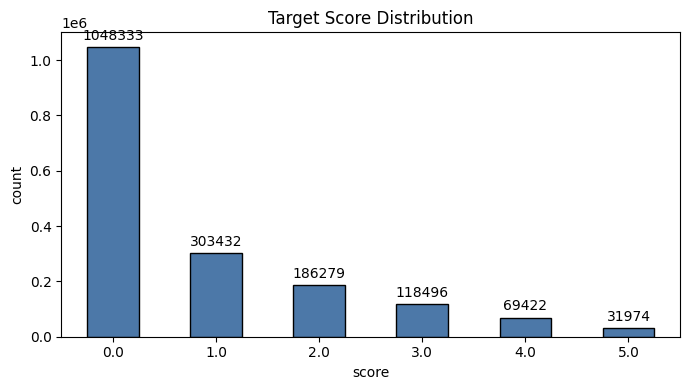

global mean: 0.83565956
global median: 0.0


In [19]:
labels = train_df.dropna(subset=["score"])
score_counts = labels["score"].value_counts().sort_index()
score_dist = pd.DataFrame({
    "count": score_counts,
    "rate": score_counts / score_counts.sum(),
})
display(score_dist)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
score_counts.plot(kind="bar", ax=ax, color="#4c78a8", edgecolor="black")
ax.set_title("Target Score Distribution")
ax.set_xlabel("score")
ax.set_ylabel("count")
ax.tick_params(axis="x", rotation=0)
ax.bar_label(ax.containers[0], fmt="%d", padding=3)
plt.tight_layout()
plt.show()

print("global mean:", labels["score"].mean())
print("global median:", labels["score"].median())

## Weather Summary

These summaries help identify scale differences and outliers before feature engineering.

In [20]:
display(train_df[WEATHER_COLS].describe().T)
display(test_df[WEATHER_COLS].describe().T)

,count,mean,std,min,25%,50%,75%,max
prec,12319040.0,2.563559,6.215294,0.000000,0.00,0.140000,2.020000,243.320007
surf_pre,12319040.0,95.936409,6.024206,66.120003,94.50,97.860001,99.889999,104.320000
humidity,12319040.0,7.799983,4.728642,0.120000,3.77,6.760000,11.320000,22.920000
tmp,12319040.0,12.949157,10.964134,-37.340000,4.68,14.200000,22.049999,41.389999
dp_tmp,12319040.0,6.781904,10.267199,-37.700001,-1.18,7.280000,15.450000,27.549999
wb_tmp,12319040.0,6.817224,10.196349,-37.459999,-1.15,7.280000,15.440000,27.549999
tmp_max,12319040.0,18.882389,11.563818,-32.200001,10.56,20.670000,28.080000,50.029999
tmp_min,12319040.0,7.537493,10.639241,-45.959999,-0.54,8.180000,16.260000,33.799999
tmp_range,12319040.0,11.344899,4.053180,0.020000,8.44,11.300000,14.190000,34.610001
surf_tmp,12319040.0,13.068181,11.235229,-37.189999,4.57,14.270000,22.299999,43.849998


,count,mean,std,min,25%,50%,75%,max
prec,204568.0,1.925298,4.628191,0.000000,0.000000,0.110000,1.480000,98.639999
surf_pre,204568.0,95.942238,5.969428,67.870003,94.529999,97.870003,99.830002,103.779999
humidity,204568.0,9.552843,4.378370,0.420000,5.790000,9.500000,13.060000,22.090000
tmp,204568.0,18.723120,8.463215,-25.910000,13.500000,20.600000,25.160000,39.669998
dp_tmp,204568.0,10.951538,8.637543,-28.510000,5.000000,12.750000,17.959999,26.709999
wb_tmp,204568.0,10.833376,8.535481,-25.950001,4.830000,12.550000,17.799999,26.620001
tmp_max,204568.0,25.148436,8.971018,-23.400000,20.070000,26.879999,31.670000,47.619999
tmp_min,204568.0,12.884061,8.294188,-34.820000,7.450000,14.430000,19.490000,32.299999
tmp_range,204568.0,12.264380,3.805968,0.460000,9.660000,12.390000,14.962500,28.330000
surf_tmp,204568.0,18.967197,8.748682,-27.820000,13.590000,20.830000,25.459999,42.400002


## Train/Test Region And Date Shape

The sample submission has one row per region. Test data has one 91-day weather block per same region.

In [21]:
sample_regions = set(sample_df["region_id"].astype(str))
test_regions = set(test_df["region_id"].astype(str))
train_regions = set(train_df["region_id"].astype(str))

print("sample - test missing:", len(sample_regions - test_regions))
print("test - sample extra  :", len(test_regions - sample_regions))
print("sample - train missing:", len(sample_regions - train_regions))

test_spans = test_df.groupby("region_id", sort=False)["date"].agg(["first", "last", "count"])
display(test_spans.head(10))

sample - test missing: 0
test - sample extra  : 0
sample - train missing: 0


,first,last,count
region_id,,,
R1,3020-09-18,3020-12-17,91
R1001,23102-07-17,23102-10-15,91
R1002,23104-07-24,23104-10-22,91
R1005,23110-07-03,23110-10-01,91
R1006,23112-07-03,23112-10-01,91
R1007,23114-08-07,23114-11-05,91
R1009,23118-07-31,23118-10-29,91
R1011,23122-07-17,23122-10-15,91
R1012,23124-07-24,23124-10-22,91


## Processing Logic: One 91-Day Window

The model does not ingest raw daily rows directly. It summarizes a 91-day weather window into tabular features such as 7-day mean, 28-day precipitation sum, 91-day max temperature, and recent-vs-long-term anomalies.

In [22]:
region_id = train_df["region_id"].iloc[0]
g = train_df[train_df["region_id"] == region_id].reset_index(drop=True)

scores = g["score"].to_numpy(dtype=np.float32)
label_idx = np.flatnonzero(~np.isnan(scores))
target_idx = int(label_idx[label_idx >= WINDOW_DAYS + 7 * max(HORIZONS)][0])
horizon = 1
cutoff = target_idx - 7 * horizon

window = g.iloc[cutoff - WINDOW_DAYS:cutoff]
target = g.iloc[target_idx]

print("region:", region_id)
print("window rows:", window.shape)
print("window date range:", window["date"].iloc[0], "to", window["date"].iloc[-1])
print("cutoff index:", cutoff)
print("target index:", target_idx)
print("target date:", target["date"])
print("target score:", target["score"])

window[["date", *WEATHER_COLS]].head()

region: R1
window rows: (91, 17)
window date range: 3005-02-03 to 3005-05-03
cutoff index: 125
target index: 132
target date: 3005-05-11
target score: 0.0


,date,prec,surf_pre,humidity,tmp,dp_tmp,wb_tmp,tmp_max,tmp_min,tmp_range,surf_tmp,wind,wind_max,wind_min,wind_range
34,3005-02-03,0.220000,100.739998,4.33,5.20,1.61,1.63,11.000000,-0.69,11.69,5.24,2.49,3.28,1.80,1.48
35,3005-02-04,0.000000,100.860001,3.83,4.21,0.04,0.06,12.570000,-1.70,14.27,4.28,1.97,3.34,0.97,2.38
36,3005-02-05,8.220000,100.180000,9.02,13.25,11.43,11.43,19.440001,5.52,13.92,13.24,5.03,6.33,3.41,2.92
37,3005-02-06,46.330002,99.970001,8.00,11.65,9.97,9.97,16.980000,2.84,14.14,11.53,3.17,5.28,1.28,4.01
38,3005-02-07,0.010000,100.910004,3.18,2.39,-2.38,-2.33,7.330000,-2.27,9.60,2.51,3.23,4.83,1.98,2.85


In [23]:
values = g[WEATHER_COLS].to_numpy(dtype=np.float32)
dates = g["date"].to_numpy()

features_no_score = compute_window_features(values, dates, cutoff, include_score_features=False)
print("number of weather-only features:", len(features_no_score))

feature_preview = pd.Series(features_no_score).sort_index()
display(feature_preview.head(30))
display(feature_preview[feature_preview.index.str.contains("prec")].head(30))

number of weather-only features: 617


day_index_mod_365          125.000000
day_of_year                123.000000
doy_cos                     -0.519744
doy_sin                      0.854322
dp_tmp_anom_w14_vs_w91       5.343680
dp_tmp_anom_w28_vs_w91       3.578323
dp_tmp_anom_w7_vs_w91        4.155824
dp_tmp_last                  7.440000
dp_tmp_last3_mean           13.780000
dp_tmp_last7_mean           12.977143
dp_tmp_trend_7_vs_prev7     -2.375714
dp_tmp_w14_max              19.330000
dp_tmp_w14_mean             14.165000
dp_tmp_w14_median           15.020000
dp_tmp_w14_min               6.850000
dp_tmp_w14_q10               7.920000
dp_tmp_w14_q90              18.230999
dp_tmp_w14_std               3.744830
dp_tmp_w28_max              19.330000
dp_tmp_w28_mean             12.399643
dp_tmp_w28_median           13.010000
dp_tmp_w28_min               2.800000
dp_tmp_w28_q10               6.511000
dp_tmp_w28_q90              16.509001
dp_tmp_w28_std               4.196888
dp_tmp_w56_max              19.330000
dp_tmp_w56_m

prec_anom_w14_vs_w91           1.505989
prec_anom_w28_vs_w91           0.674561
prec_anom_w7_vs_w91            4.038132
prec_last                      0.030000
prec_last3_mean               11.453334
prec_last7_mean                7.160000
prec_recent14_vs_91_daily     21.083847
prec_recent7_vs_91_daily      28.266922
prec_trend_7_vs_prev7          5.064285
prec_w14_max                  18.219999
prec_w14_mean                  4.627857
prec_w14_median                0.105000
prec_w14_min                   0.000000
prec_w14_q10                   0.000000
prec_w14_q90                  14.394000
prec_w14_std                   6.225259
prec_w14_sum                  64.790001
prec_w28_max                  18.219999
prec_w28_mean                  3.796429
prec_w28_median                0.065000
prec_w28_min                   0.000000
prec_w28_q10                   0.000000
prec_w28_q90                  12.106001
prec_w28_std                   5.643182
prec_w28_sum                 106.300003


## Score Feature Mismatch Check

If score features are used, training should only use score history before the 91-day weather window starts. Test windows have no `score` labels inside the 91-day block, so using labels inside the training weather window would create a train/test mismatch.

In [24]:
X_score, y_score, meta_score = build_training_set_for_horizon(
    train_df[train_df["region_id"] == region_id],
    horizon=1,
    stride=100,
    max_train_examples=3,
    include_score_features=True,
)
X_no_score, y_no_score, meta_no_score = build_training_set_for_horizon(
    train_df[train_df["region_id"] == region_id],
    horizon=1,
    stride=100,
    max_train_examples=3,
    include_score_features=False,
)

print("with score features:", X_score.shape)
print("without score features:", X_no_score.shape)
print("score columns:", [c for c in X_score.columns if c.startswith("score_")])
print("no-score columns:", [c for c in X_no_score.columns if c.startswith("score_")])

display(pd.concat([meta_score, X_score[[c for c in X_score.columns if c.startswith("score_")]]], axis=1))

with score features: (3, 625)
without score features: (3, 617)
score columns: ['score_last', 'score_mean_all', 'score_median_all', 'score_severe_freq_all', 'score_mean_last2', 'score_mean_last4', 'score_mean_last8', 'score_trend_last_vs_last8']
no-score columns: []


,region_id,cutoff_idx,target_idx,score_last,score_mean_all,score_median_all,score_severe_freq_all,score_mean_last2,score_mean_last4,score_mean_last8,score_trend_last_vs_last8
0,R1,125,132,0.0,0.000000,0.0,0.000000,0.0,0.00,0.000,0.000
1,R1,2925,2932,3.0,1.232673,1.0,0.210396,3.5,3.75,3.375,-0.375
2,R1,5025,5032,0.0,1.089489,1.0,0.161932,0.0,0.00,0.250,-0.250


## Build A Small Processed Dataset

Use this for quick experiments and to inspect the final supervised table structure. Increase `max_regions` or remove it when you are ready to build full training features.

In [25]:
small_train_df = read_train_csv(TRAIN_CSV, max_regions=5)
X_small, y_small, meta_small = build_training_set_for_horizon(
    small_train_df,
    horizon=1,
    stride=8,
    max_train_examples=200,
    include_score_features=False,
)

processed_small = pd.concat([
    meta_small.reset_index(drop=True),
    pd.Series(y_small, name="y"),
    X_small.reset_index(drop=True),
], axis=1)

print(processed_small.shape)
display(processed_small.head())

(200, 621)


,region_id,cutoff_idx,target_idx,y,prec_w7_mean,prec_w7_std,prec_w7_min,prec_w7_max,prec_w7_median,prec_w7_q10,prec_w7_q90,surf_pre_w7_mean,surf_pre_w7_std,surf_pre_w7_min,surf_pre_w7_max,surf_pre_w7_median,surf_pre_w7_q10,surf_pre_w7_q90,humidity_w7_mean,humidity_w7_std,humidity_w7_min,humidity_w7_max,humidity_w7_median,humidity_w7_q10,humidity_w7_q90,tmp_w7_mean,tmp_w7_std,tmp_w7_min,tmp_w7_max,tmp_w7_median,tmp_w7_q10,tmp_w7_q90,dp_tmp_w7_mean,dp_tmp_w7_std,dp_tmp_w7_min,dp_tmp_w7_max,dp_tmp_w7_median,dp_tmp_w7_q10,dp_tmp_w7_q90,wb_tmp_w7_mean,...,humidity_anom_w14_vs_w91,tmp_anom_w14_vs_w91,dp_tmp_anom_w14_vs_w91,wb_tmp_anom_w14_vs_w91,tmp_max_anom_w14_vs_w91,tmp_min_anom_w14_vs_w91,tmp_range_anom_w14_vs_w91,surf_tmp_anom_w14_vs_w91,wind_anom_w14_vs_w91,wind_max_anom_w14_vs_w91,wind_min_anom_w14_vs_w91,wind_range_anom_w14_vs_w91,prec_anom_w28_vs_w91,surf_pre_anom_w28_vs_w91,humidity_anom_w28_vs_w91,tmp_anom_w28_vs_w91,dp_tmp_anom_w28_vs_w91,wb_tmp_anom_w28_vs_w91,tmp_max_anom_w28_vs_w91,tmp_min_anom_w28_vs_w91,tmp_range_anom_w28_vs_w91,surf_tmp_anom_w28_vs_w91,wind_anom_w28_vs_w91,wind_max_anom_w28_vs_w91,wind_min_anom_w28_vs_w91,wind_range_anom_w28_vs_w91,max_consecutive_dry_days_w91,prec_recent7_vs_91_daily,prec_recent14_vs_91_daily,hot_dry_w7,hot_dry_w28,evap_risk_w7,surface_heat_low_humidity_w7,dry_fraction_w91,month,day_of_year,week_of_year,day_index_mod_365,doy_sin,doy_cos
0,R1,125,132,0.0,7.160000,7.154075,0.0,18.219999,6.57,0.018,16.954000,100.358574,0.295027,99.930000,100.709999,100.400002,99.930000,100.692001,9.852858,3.065675,6.24,14.110000,10.61,6.354000,13.858000,17.672857,2.808109,12.880000,22.209999,17.049999,14.734000,20.980000,12.977143,4.857864,6.85,19.33,14.570000,7.204,19.108000,12.981428,...,2.850604,6.010054,5.343680,5.338241,5.616262,6.213790,-0.596704,6.168570,-0.112088,-0.129121,0.008077,-0.137747,0.674561,-0.247536,1.794534,4.512197,3.578323,3.573600,4.744120,4.146647,0.597223,4.527855,-0.161016,-0.264478,-0.135852,-0.128462,7.0,28.266922,21.083847,0.458417,0.227659,12.798320,1.636040,0.395604,5.0,123.0,18.0,125.0,0.854322,-0.519744
1,R1,237,244,0.0,5.780000,6.916502,0.0,19.010000,1.14,0.000,13.694000,100.218575,0.109730,100.080002,100.360001,100.209999,100.092003,100.348000,14.431429,2.924109,10.66,17.559999,16.01,10.744000,17.379999,25.232859,1.054172,23.469999,27.180000,25.280001,24.058001,26.309999,19.420000,3.376037,14.96,22.92,21.400000,15.086,22.751999,19.420000,...,-1.956045,-2.249996,-2.432968,-2.432802,-1.680439,-2.883570,1.201486,-2.381817,-0.025494,0.008132,-0.071154,0.082088,0.137610,-0.044586,-1.525331,-0.500359,-1.877968,-1.877800,0.420633,-1.302500,1.722913,-0.464317,0.055577,0.022418,0.047775,-0.024341,3.0,14.790768,35.341537,0.751258,0.301388,7.223069,1.618126,0.153846,8.0,235.0,34.0,237.0,-0.785650,-0.618671
2,R1,405,412,0.0,5.240000,8.066065,0.0,21.780001,0.21,0.000,16.548000,100.901428,0.178920,100.620003,101.120003,100.839996,100.697998,101.096001,5.578571,0.870212,4.57,7.540000,5.45,4.810000,6.382000,7.617143,1.991494,5.950000,11.920000,6.820000,5.974000,10.108000,5.264286,1.999527,2.62,9.57,5.090000,3.316,7.146000,5.270000,...,-1.072966,-2.135604,-1.422143,-1.440330,-2.916867,-1.458790,-1.457967,-1.949780,0.092912,0.053901,0.047418,0.006484,-0.421401,0.082787,-1.083323,-2.349891,-2.457856,-2.444973,-2.451868,-2.288076,-0.163324,-2.241209,0.203626,0.257115,0.097418,0.159341,12.0,11.147692,11.175385,0.345238,0.134551,11.709126,1.157003,0.461538,2.0,38.0,6.0,40.0,0.608477,0.793572
3,R1,517,524,0.0,5.648571,8.926766,0.0,22.510000,0.00,0.000,18.940001,99.762863,0.246908,99.239998,100.029999,99.860001,99.486000,99.970001,12.082857,2.058430,9.37,14.570000,12.72,9.532001,14.432000,21.692858,1.647394,18.959999,23.889999,22.010000,19.386000,23.464001,16.604288,2.708652,12.87,19.77,17.620001,13.182,19.638000,16.605715,...,3.441538,6.270714,5.546759,5.543297,6.290880,6.373350,-0.083955,6.279064,-0.462857,-0.699670,-0.238077,-0.460879,-2.033571,0.056068,2.481895,4.787144,4.245684,4.2418

## Build Test Features

This shows the processed table that will be fed to prediction models for Kaggle submission.

In [26]:
small_test_df = read_test_csv(TEST_CSV, max_regions=5)
X_test_small, test_meta_small = build_test_features(
    small_test_df,
    train_df=None,
    include_score_features=False,
)
processed_test_small = pd.concat([test_meta_small, X_test_small], axis=1)

print(processed_test_small.shape)
display(processed_test_small.head())

(5, 618)


,region_id,prec_w7_mean,prec_w7_std,prec_w7_min,prec_w7_max,prec_w7_median,prec_w7_q10,prec_w7_q90,surf_pre_w7_mean,surf_pre_w7_std,surf_pre_w7_min,surf_pre_w7_max,surf_pre_w7_median,surf_pre_w7_q10,surf_pre_w7_q90,humidity_w7_mean,humidity_w7_std,humidity_w7_min,humidity_w7_max,humidity_w7_median,humidity_w7_q10,humidity_w7_q90,tmp_w7_mean,tmp_w7_std,tmp_w7_min,tmp_w7_max,tmp_w7_median,tmp_w7_q10,tmp_w7_q90,dp_tmp_w7_mean,dp_tmp_w7_std,dp_tmp_w7_min,dp_tmp_w7_max,dp_tmp_w7_median,dp_tmp_w7_q10,dp_tmp_w7_q90,wb_tmp_w7_mean,wb_tmp_w7_std,wb_tmp_w7_min,wb_tmp_w7_max,...,humidity_anom_w14_vs_w91,tmp_anom_w14_vs_w91,dp_tmp_anom_w14_vs_w91,wb_tmp_anom_w14_vs_w91,tmp_max_anom_w14_vs_w91,tmp_min_anom_w14_vs_w91,tmp_range_anom_w14_vs_w91,surf_tmp_anom_w14_vs_w91,wind_anom_w14_vs_w91,wind_max_anom_w14_vs_w91,wind_min_anom_w14_vs_w91,wind_range_anom_w14_vs_w91,prec_anom_w28_vs_w91,surf_pre_anom_w28_vs_w91,humidity_anom_w28_vs_w91,tmp_anom_w28_vs_w91,dp_tmp_anom_w28_vs_w91,wb_tmp_anom_w28_vs_w91,tmp_max_anom_w28_vs_w91,tmp_min_anom_w28_vs_w91,tmp_range_anom_w28_vs_w91,surf_tmp_anom_w28_vs_w91,wind_anom_w28_vs_w91,wind_max_anom_w28_vs_w91,wind_min_anom_w28_vs_w91,wind_range_anom_w28_vs_w91,max_consecutive_dry_days_w91,prec_recent7_vs_91_daily,prec_recent14_vs_91_daily,hot_dry_w7,hot_dry_w28,evap_risk_w7,surface_heat_low_humidity_w7,dry_fraction_w91,month,day_of_year,week_of_year,day_index_mod_365,doy_sin,doy_cos
0,R1,6.612857,8.939022,0.03,25.520000,3.42,0.036,18.493999,100.402855,0.657283,99.650002,101.540001,100.180000,99.800003,101.365997,6.594285,2.479463,3.43,11.50,6.36,3.850,9.520000,8.935715,4.078417,4.450000,16.920000,8.290000,4.534000,14.148000,6.908571,5.333324,-1.19,16.129999,7.140000,0.298,13.046000,6.625714,5.365748,-1.22,16.070000,...,-1.620715,-5.868958,-2.685769,-2.677087,-6.837860,-4.733737,-2.104012,-5.986319,0.381648,0.471099,0.282033,0.188132,0.578379,0.021545,-1.766072,-5.410743,-2.977911,-2.989944,-6.140362,-4.971593,-1.168296,-5.541676,0.318791,0.382885,0.272033,0.110989,9.0,25.526154,23.082306,0.315651,0.171225,12.077059,1.154628,0.395604,12.0,351.0,51.0,91.0,-0.238673,0.971100
1,R1001,4.608571,7.303743,0.00,17.209999,0.01,0.000,15.901999,100.151428,0.206289,99.809998,100.529999,100.129997,99.923996,100.368004,7.798572,2.842180,3.98,11.89,8.81,4.232,10.756001,15.692857,4.082323,9.500000,22.540001,16.430000,10.724000,20.068001,9.300001,5.905436,0.65,16.770000,12.180000,1.454,15.108000,9.028571,5.727234,0.63,16.629999,...,-5.287747,-5.921431,-7.770275,-7.851155,-3.934669,-7.783080,3.847528,-5.686594,0.731593,1.096428,0.454121,0.640660,0.452802,0.052498,-3.566676,-2.402857,-4.780276,-4.858296,-0.978243,-3.535579,2.556813,-2.185879,0.570522,0.996428,0.333407,0.662088,11.0,16.714615,34.989235,0.709089,0.386162,22.680582,1.804351,0.439560,10.0,288.0,42.0,91.0,-0.970064,0.242850
2,R1002,3.351429,5.731961,0.00,16.320000,0.08,0.006,10.416000,98.934280,0.255949,98.489998,99.269997,98.930000,98.652000,99.239998,7.240000,2.136392,4.96,11.01,6.07,5.116,10.134000,12.905715,3.018698,8.870000,17.430000,12.300000,9.764000,17.040001,8.468572,4.125930,3.62,15.230000,6.450000,4.046,13.970000,8.247142,4.117578,3.58,15.090000,...,-4.925605,-9.035441,-7.886153,-7.942416,-7.980436,-9.978790,1.997308,-9.097580,0.564451,0.880055,0.250275,0.630275,1.534506,-0.043846,-3.125248,-4.196156,-4.708652,-4.776702,-3.306511,-4.853433,1.545877,-4.185793,0.456236,0.790412,0.226703,0.564204,12.0,7.201538,5.893078,0.809718,0.238896,18.710358,1.572642,0.373626,10.0,295.0,43.0,91.0,-0.933837,0.357698
3,R1005,0.107143,0.238849,0.00,0.690000,0.00,0.000,0.312000,99.654289,0.312313,99.190002,100.110001,99.730003,99.286003,100.032005,12.150001,1.527313,9.74,13.58,13.13,10.226,13.556000,25.524286,2.439290,22.020000,28.219999,26.490000,22.158001,27.986000,16.950001,2.085439,13.60,18.850000,18.370001,14.314,18.837999,16.605715,2.311103,12.88,18.680000,...,-3.151485,-0.095058,-3.638737,-3.754339,1.345053,-1.228132,2.575331,-0.033243,0.325550,0.644341,0.050110,0.593